# **Steg 9: Träna ML-modell i Google Colab**

**CELL 1 - Importera bibliotek**

In [ ]:
# ============================================
# CELL 1: Importera bibliotek
# ============================================

# Grundläggande bibliotek för datahantering
import pandas as pd
import numpy as np

# Bibliotek för maskininlärning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# För att spara modellen
import joblib
import os
import zipfile

# För att ladda ner filer
from google.colab import files

# För att visa snygga diagram (valfritt men trevligt)
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ CELL 1 KLAR: Alla bibliotek är importerade!")

✅ CELL 1 KLAR: Alla bibliotek är importerade!


**CELL 2 - Skapa träningsdata som matchar SQL-databasen**

🔄 Skapar 5000 rader med nätverkstrafikdata...
🔄 Skapar labels (normal/attack)...

📊 DATASTATISTIK:
   Totalt antal rader: 5000
   Normal trafik (0): 4478 (89.6%)
   Skadlig trafik (1): 522 (10.4%)

📊 ATTACKTYPER:
AttackType
Normal            4478
Unknown Attack     393
Port Scan          123
Brute Force          5
DDoS                 1
Name: count, dtype: int64

📋 Första 5 raderna i datasetet:
  Protocol  SourcePort  DestinationPort  PacketSize  Duration  BytesSent  \
0      TCP       20530              733         706      4.42      50168   
1     ICMP       41959              326         774      1.14      50041   
2      UDP        6214              529        1118      0.75      49765   
3      TCP        5599              892         916      4.96      50011   
4      TCP       41519               89         939      1.04      50316   

   BytesReceived  IsMalicious AttackType  
0         200263            0     Normal  
1         199870            0     Normal  
2         199463

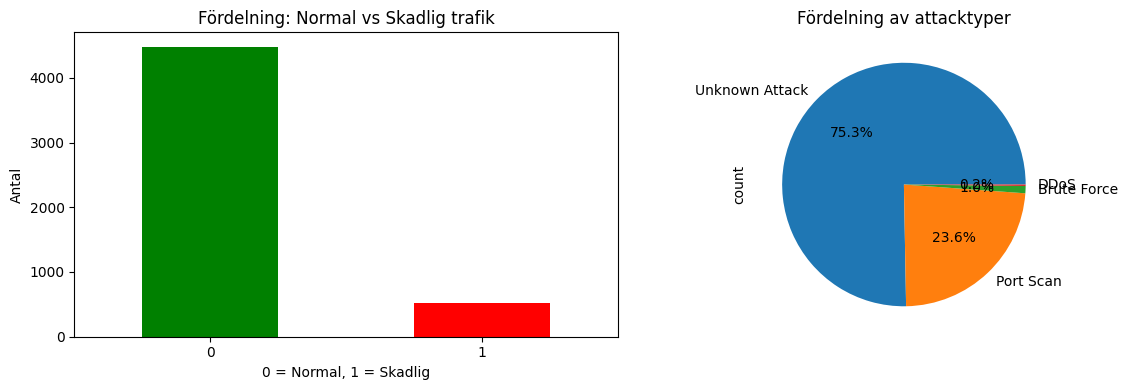


✅ CELL 2 KLAR: Träningsdata är skapad!


In [ ]:
# ============================================
# CELL 2: Skapa träningsdata (matchar vår SQL-databas)
# ============================================

# För att resultaten ska bli samma varje gång (reproducerbart)
np.random.seed(42)

# Antal rader vi vill skapa
antal_rader = 5000

print(f"🔄 Skapar {antal_rader} rader med nätverkstrafikdata...")

# Generera data
data = {
    'Protocol': np.random.choice(['TCP', 'UDP', 'ICMP'], antal_rader, p=[0.7, 0.2, 0.1]),
    'SourcePort': np.random.randint(1024, 65535, antal_rader),
    'DestinationPort': np.random.randint(1, 1024, antal_rader),
    'PacketSize': np.random.normal(800, 400, antal_rader),
    'Duration': np.random.exponential(2, antal_rader),
    'BytesSent': np.random.poisson(50000, antal_rader),
    'BytesReceived': np.random.poisson(200000, antal_rader)
}

# Skapa DataFrame
df = pd.DataFrame(data)

# Runda av decimaltal (gör datan snyggare)
df['PacketSize'] = df['PacketSize'].round(0).astype(int)
df['Duration'] = df['Duration'].round(2)
df['BytesSent'] = df['BytesSent'].astype(int)
df['BytesReceived'] = df['BytesReceived'].astype(int)

# Se till att värden är positiva
df['PacketSize'] = df['PacketSize'].abs()
df['PacketSize'] = df['PacketSize'].clip(lower=40, upper=1500)  # Min/Max paketstorlek
df['Duration'] = df['Duration'].clip(lower=0.01, upper=30)      # Min/Max duration

# ============================================
# Skapa labels (0 = normal, 1 = attack)
# ============================================
print("🔄 Skapar labels (normal/attack)...")

# Börja med att alla är normala (0)
df['IsMalicious'] = 0

# Definiera regler för vad som är en attack
attack_conditions = (
    (df['DestinationPort'] < 25) |                    # Ovanliga portar (systemportar)
    (df['PacketSize'] < 100) |                         # Ovanligt små paket
    (df['Duration'] < 0.1) |                           # Ovanligt korta anslutningar
    ((df['BytesSent'] > df['BytesReceived'] * 10)) |   # Mycket mer skickat än mottaget
    (df['DestinationPort'].isin([22, 23, 3389, 445]))  # Kända attackportar (SSH, Telnet, RDP, SMB)
)

# Sätt attacklabel (1) där villkoren uppfylls
df.loc[attack_conditions, 'IsMalicious'] = 1

# Skapa en kolumn för attacktyp (för förklaring)
def bestäm_attacktyp(row):
    if row['IsMalicious'] == 0:
        return 'Normal'
    elif row['DestinationPort'] in [22, 3389]:
        return 'Brute Force'
    elif row['DestinationPort'] in [80, 443] and row['PacketSize'] < 200:
        return 'DDoS'
    elif row['DestinationPort'] < 25:
        return 'Port Scan'
    elif row['BytesSent'] > row['BytesReceived'] * 10:
        return 'Data Exfiltration'
    else:
        return 'Unknown Attack'

df['AttackType'] = df.apply(bestäm_attacktyp, axis=1)

# ============================================
# Visa statistik om datan
# ============================================
print("\n📊 DATASTATISTIK:")
print(f"   Totalt antal rader: {len(df)}")
print(f"   Normal trafik (0): {len(df[df['IsMalicious']==0])} ({len(df[df['IsMalicious']==0])/len(df)*100:.1f}%)")
print(f"   Skadlig trafik (1): {len(df[df['IsMalicious']==1])} ({len(df[df['IsMalicious']==1])/len(df)*100:.1f}%)")

print("\n📊 ATTACKTYPER:")
print(df['AttackType'].value_counts())

# Visa de första 5 raderna
print("\n📋 Första 5 raderna i datasetet:")
print(df.head())

# Visa grundläggande statistik
print("\n📋 Statistisk sammanfattning:")
print(df.describe())

# Visualisera fördelningen (valfritt)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['IsMalicious'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Fördelning: Normal vs Skadlig trafik')
plt.xlabel('0 = Normal, 1 = Skadlig')
plt.ylabel('Antal')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
attack_counts = df[df['IsMalicious']==1]['AttackType'].value_counts()
if not attack_counts.empty:
    attack_counts.plot(kind='pie', autopct='%1.1f%%')
    plt.title('Fördelning av attacktyper')
else:
    plt.text(0.5, 0.5, 'Inga attacker i datasetet', ha='center')

plt.tight_layout()
plt.show()

print("\n✅ CELL 2 KLAR: Träningsdata är skapad!")

**CELL 3 - Förbereda data för maskininlärning**

In [ ]:
# ============================================
# CELL 3: Förbereda data för maskininlärning
# ============================================

print("🔄 Förbereder data för ML-modellen...")

# ============================================
# Hantera kategoriska variabler (omvandla text till nummer)
# ============================================

# 'Protocol' är text (TCP, UDP, ICMP) - måste bli siffror
print("   - Omvandlar kategoriska variabler...")

# Använd one-hot encoding (skapar separata kolumner för TCP, UDP, ICMP)
df_encoded = pd.get_dummies(df, columns=['Protocol'], prefix='Protocol')

print(f"   - Antal kolumner efter encoding: {df_encoded.shape[1]}")

# ============================================
# Separera features (X) och target (y)
# ============================================
print("   - Separerar features och target...")

# Features (X) = allt utom IsMalicious och AttackType
X = df_encoded.drop(['IsMalicious', 'AttackType'], axis=1)

# Target (y) = det vi vill predicera (IsMalicious)
y = df_encoded['IsMalicious']

print(f"   - Features (X): {X.shape[1]} kolumner")
print(f"   - Target (y): {y.name}")

# ============================================
# Dela upp i träningsdata och testdata
# ============================================
print("   - Delar upp i träning (80%) och test (20%)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% till test
    random_state=42,        # För reproducerbarhet
    stratify=y              # Behåll samma fördelning av attacker i träning/test
)

print(f"   - Träningsdata: {len(X_train)} rader")
print(f"   - Testdata: {len(X_test)} rader")
print(f"   - Fördelning i träning: {y_train.value_counts().to_dict()}")
print(f"   - Fördelning i test: {y_test.value_counts().to_dict()}")

# ============================================
# Visa kolumnnamnen (viktigt för senare!)
# ============================================
print("\n📋 Kolumner i X (features):")
feature_list = X.columns.tolist()
for i, col in enumerate(feature_list[:10]):  # Visa första 10
    print(f"   {i+1}. {col}")
if len(feature_list) > 10:
    print(f"   ... och {len(feature_list)-10} fler")

print("\n✅ CELL 3 KLAR: Data är förberedd för träning!")

🔄 Förbereder data för ML-modellen...
   - Omvandlar kategoriska variabler...
   - Antal kolumner efter encoding: 11
   - Separerar features och target...
   - Features (X): 9 kolumner
   - Target (y): IsMalicious
   - Delar upp i träning (80%) och test (20%)...
   - Träningsdata: 4000 rader
   - Testdata: 1000 rader
   - Fördelning i träning: {0: 3582, 1: 418}
   - Fördelning i test: {0: 896, 1: 104}

📋 Kolumner i X (features):
   1. SourcePort
   2. DestinationPort
   3. PacketSize
   4. Duration
   5. BytesSent
   6. BytesReceived
   7. Protocol_ICMP
   8. Protocol_TCP
   9. Protocol_UDP

✅ CELL 3 KLAR: Data är förberedd för träning!


**CELL 4 - Träna själva modellen (Random Forest)**

🔄 Skapar och tränar Random Forest-modell...
   (Detta kan ta några sekunder...)
   - Modell skapad med följande parametrar:
     • n_estimators: 100
     • max_depth: 10
     • min_samples_split: 5
     • min_samples_leaf: 2

🔄 Tränar modellen...
✅ Modellträning klar!

📊 TOPP 10 VIKTIGASTE FEATURES:
   4. Duration: 0.4692
   3. PacketSize: 0.2942
   2. DestinationPort: 0.2203
   1. SourcePort: 0.0057
   6. BytesReceived: 0.0052
   5. BytesSent: 0.0048
   8. Protocol_TCP: 0.0004
   9. Protocol_UDP: 0.0001
   7. Protocol_ICMP: 0.0001


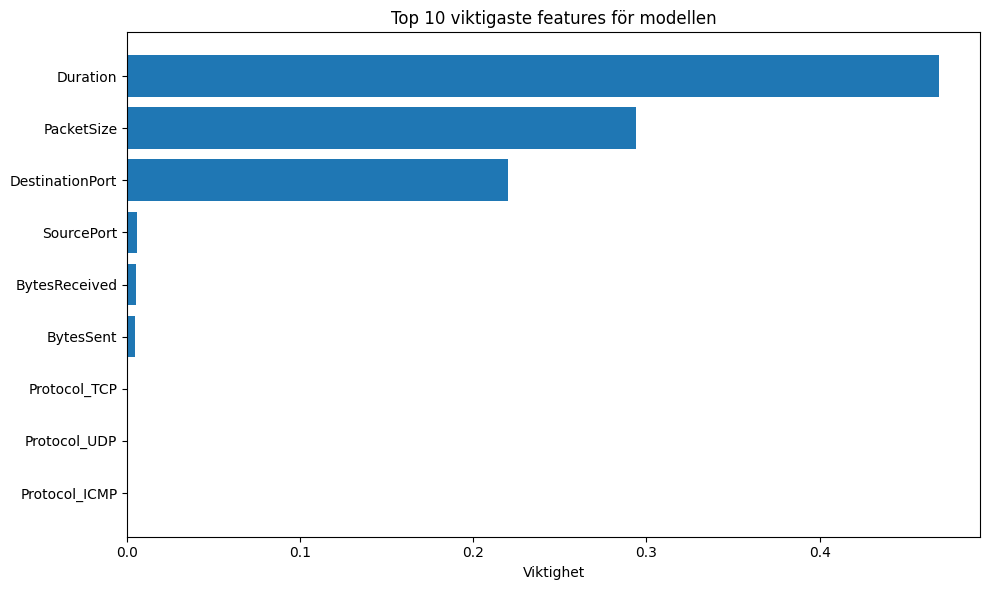


✅ CELL 4 KLAR: Modellen är tränad!


In [ ]:
# ============================================
# CELL 4: Träna Random Forest-modellen
# ============================================

print("🔄 Skapar och tränar Random Forest-modell...")
print("   (Detta kan ta några sekunder...)")

# ============================================
# Skapa modellen med bra inställningar för nybörjare
# ============================================
model = RandomForestClassifier(
    n_estimators=100,        # Antal träd (standard är 100, bra för nybörjare)
    max_depth=10,             # Max djup på träden (för att undvika överanpassning)
    min_samples_split=5,      # Minsta antal samples för att dela en nod
    min_samples_leaf=2,       # Minsta antal samples i en lövnod
    random_state=42,          # För reproducerbarhet
    n_jobs=-1                 # Använd alla processorer (snabbare träning)
)

print("   - Modell skapad med följande parametrar:")
print(f"     • n_estimators: 100")
print(f"     • max_depth: 10")
print(f"     • min_samples_split: 5")
print(f"     • min_samples_leaf: 2")

# ============================================
# Träna modellen
# ============================================
print("\n🔄 Tränar modellen...")
model.fit(X_train, y_train)

print("✅ Modellträning klar!")

# ============================================
# Visa feature importance (vilka kolumner är viktigast?)
# ============================================
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 TOPP 10 VIKTIGASTE FEATURES:")
for i, row in feature_importance.head(10).iterrows():
    print(f"   {i+1}. {row['feature']}: {row['importance']:.4f}")

# Visualisera feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Viktighet')
plt.title('Top 10 viktigaste features för modellen')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n✅ CELL 4 KLAR: Modellen är tränad!")

**CELL 5 - Testa och utvärdera modellen**

🔄 Utvärderar modellen på testdata...

🎯 Noggrannhet (Accuracy): 0.9990 (99.90%)

📊 KLASSIFICERINGSRAPPORT:
   (precision = hur många av de vi flaggade som attacker var verkligen attacker?)
   (recall = hur många av de verkliga attackerna hittade vi?)
   (f1-score = balans mellan precision och recall)
------------------------------------------------------------
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00       896
  Attack (1)       1.00      0.99      1.00       104

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


📊 FÖRVIRRINGSMATRIS (Confusion Matrix):
                     Predikterad
                     Normal   Attack
Faktisk Normal         896        0
Faktisk Attack           1      103
--------------------------------------------------
TN = 896 | FP = 0  (falska larm)
FN = 1 | TP = 103  (upptäckta attacker)


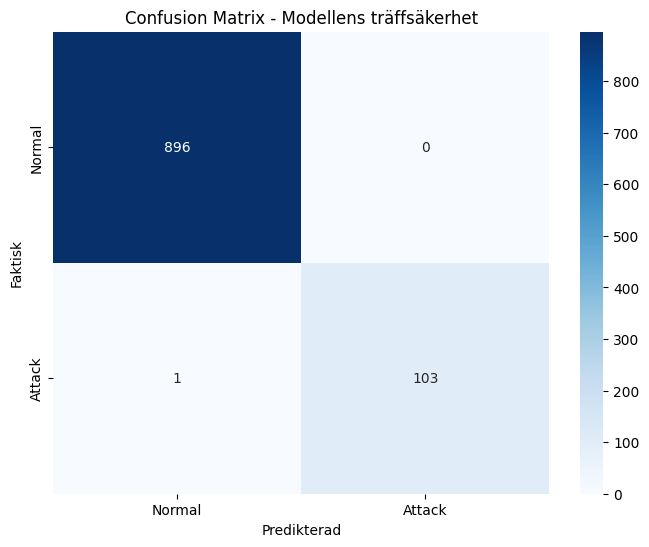


📈 SAMMANFATTNING FÖR ATTACKDETEKTERING:
   • Precision (hur många larm var korrekta?): 100.00%
   • Recall (hur många attacker hittade vi?): 99.04%
   • F1-score (balans): 99.52%
   ✅ Bra! Modellen hittar de flesta attacker.
   ✅ Bra! Modellen har få falska larm.

✅ CELL 5 KLAR: Modellen är utvärderad!


In [ ]:
# ============================================
# CELL 5: Testa och utvärdera modellen
# ============================================

print("🔄 Utvärderar modellen på testdata...")

# ============================================
# Gör prediktioner på testdata
# ============================================
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# ============================================
# Beräkna noggrannhet (accuracy)
# ============================================
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Noggrannhet (Accuracy): {accuracy:.4f} ({accuracy*100:.2f}%)")

# ============================================
# Detaljerad utvärdering (classification report)
# ============================================
print("\n📊 KLASSIFICERINGSRAPPORT:")
print("   (precision = hur många av de vi flaggade som attacker var verkligen attacker?)")
print("   (recall = hur många av de verkliga attackerna hittade vi?)")
print("   (f1-score = balans mellan precision och recall)")
print("-" * 60)

report = classification_report(y_test, y_pred,
                              target_names=['Normal (0)', 'Attack (1)'],
                              output_dict=True)

print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Attack (1)']))

# ============================================
# Confusion Matrix (förvirringsmatris)
# ============================================
cm = confusion_matrix(y_test, y_pred)

print("\n📊 FÖRVIRRINGSMATRIS (Confusion Matrix):")
print("                     Predikterad")
print("                     Normal   Attack")
print(f"Faktisk Normal      {cm[0,0]:6d}   {cm[0,1]:6d}")
print(f"Faktisk Attack      {cm[1,0]:6d}   {cm[1,1]:6d}")
print("-" * 50)
print(f"TN = {cm[0,0]} | FP = {cm[0,1]}  (falska larm)")
print(f"FN = {cm[1,0]} | TP = {cm[1,1]}  (upptäckta attacker)")

# Visualisera confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.xlabel('Predikterad')
plt.ylabel('Faktisk')
plt.title('Confusion Matrix - Modellens träffsäkerhet')
plt.show()

# ============================================
# Extrahera viktiga mått
# ============================================
precision_attack = report['Attack (1)']['precision']
recall_attack = report['Attack (1)']['recall']
f1_attack = report['Attack (1)']['f1-score']

print("\n📈 SAMMANFATTNING FÖR ATTACKDETEKTERING:")
print(f"   • Precision (hur många larm var korrekta?): {precision_attack:.2%}")
print(f"   • Recall (hur många attacker hittade vi?): {recall_attack:.2%}")
print(f"   • F1-score (balans): {f1_attack:.2%}")

if recall_attack > 0.8:
    print("   ✅ Bra! Modellen hittar de flesta attacker.")
else:
    print("   ⚠️ Modellen missar många attacker - kan behöva förbättras.")

if precision_attack > 0.8:
    print("   ✅ Bra! Modellen har få falska larm.")
else:
    print("   ⚠️ Modellen har många falska larm - kan behöva justeras.")

print("\n✅ CELL 5 KLAR: Modellen är utvärderad!")

**CELL 6 - Spara den tränade modellen som .pkl-fil**

In [ ]:
# ============================================
# CELL 6: Spara den tränade modellen (KORRIGERAD)
# ============================================

print("🔄 Sparar den tränade modellen...")

# ============================================
# Skapa mapp för modellen
# ============================================
model_dir = 'network_model'
os.makedirs(model_dir, exist_ok=True)
print(f"   - Mapp skapad: {model_dir}/")

# ============================================
# Spara själva modellen
# ============================================
model_path = os.path.join(model_dir, 'network_intrusion_model.pkl')
joblib.dump(model, model_path)
print(f"   ✅ Modell sparad: {model_path}")

# ============================================
# Spara feature names (otroligt viktigt!)
# ============================================
feature_path = os.path.join(model_dir, 'feature_columns.pkl')
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, feature_path)
print(f"   ✅ Feature columns sparade: {feature_path}")
print(f"      (Detta behövs för att förbereda nya data på samma sätt)")

# ============================================
# Spara modell-metadata (information om modellen)
# ============================================
metadata = {
    'model_type': 'Random Forest Classifier',
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_samples': len(df),
    'n_features': X.shape[1],
    'accuracy': accuracy,
    'precision_attack': precision_attack,
    'recall_attack': recall_attack,
    'f1_attack': f1_attack,
    'feature_importance': feature_importance.head(10).to_dict(),
    'description': 'Nätverksintrångsdetektering - klassificerar trafik som normal eller attack'
}

metadata_path = os.path.join(model_dir, 'model_metadata.pkl')
joblib.dump(metadata, metadata_path)
print(f"   ✅ Metadata sparat: {metadata_path}")

# ============================================
# Skapa en enkel README-fil
# ============================================
readme_content = f"""
# NETWORK SECURITY ML MODEL
Skapad: {metadata['training_date']}

## Modellbeskrivning
{metadata['description']}

## Prestanda
- Noggrannhet: {metadata['accuracy']:.2%}
- Precision (attacker): {metadata['precision_attack']:.2%}
- Recall (attacker): {metadata['recall_attack']:.2%}
- F1-score: {metadata['f1_attack']:.2%}

## Filer i denna mapp
- network_intrusion_model.pkl : Den tränade modellen
- feature_columns.pkl : Lista över kolumner som modellen förväntar sig
- model_metadata.pkl : Information om modellen och dess prestanda

## Användning i produktion
1. Ladda modellen: joblib.load('network_intrusion_model.pkl')
2. Ladda feature columns: joblib.load('feature_columns.pkl')
3. Förbered ny data med exakt samma kolumner
4. Gör prediktioner med model.predict(X_new)
"""

readme_path = os.path.join(model_dir, 'README.txt')
with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(readme_content)
print(f"   ✅ README skapad: {readme_path}")

# ============================================
# Skapa en zip-fil för nedladdning
# ============================================
print("\n🔄 Skapar zip-fil för nedladdning...")

import zipfile
zip_filename = 'network_model.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for root, dirs, files in os.walk(model_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, start=os.path.dirname(model_dir))
            zipf.write(file_path, arcname)

print(f"   ✅ Zip-fil skapad: {zip_filename}")
print(f"   📦 Zip-filen innehåller:")
for file in os.listdir(model_dir):
    file_size = os.path.getsize(os.path.join(model_dir, file)) / 1024  # KB
    print(f"      • {file} ({file_size:.1f} KB)")

# ============================================
# Ladda ner zip-filen till din dator (KORRIGERAD)
# ============================================
print("\n📥 Laddar ner modellen till din dator...")
print("   (En fil kommer att laddas ner automatiskt inom några sekunder)")
print("   Filen sparas vanligtvis i mappen 'Nedladdningar' (Downloads)")

# KORRIGERING: Se till att vi importerar files från google.colab
from google.colab import files
files.download('network_model.zip')  # Detta är en sträng, inte en lista!

# ============================================
# Visa sammanfattning
# ============================================
print("\n" + "="*60)
print("🎯 SAMMANFATTNING - TRÄNING KLAR!")
print("="*60)
print(f"""
📊 MODELLPRESTANDA:
   • Noggrannhet: {accuracy:.2%}
   • Precision (attacker): {precision_attack:.2%}
   • Recall (attacker): {recall_attack:.2%}
   • F1-score: {f1_attack:.2%}

📁 FILER SOM LADDAS NER:
   • network_model.zip (innehåller allt)

📂 NÄSTA STEG:
   1. Packa upp network_model.zip i din projektmapp
      (t.ex. C:\\ML_SQL_Project\\)
   2. Mappen kommer att heta 'network_model' med filerna:
      - network_intrusion_model.pkl
      - feature_columns.pkl
      - model_metadata.pkl
      - README.txt
   3. Du är redo för steg 10 - kör Python-skriptet i VS Code!
""")

print("\n✅ CELL 6 KLAR: Allt är klart! Modellen är tränad och sparad.")

🔄 Sparar den tränade modellen...
   - Mapp skapad: network_model/
   ✅ Modell sparad: network_model/network_intrusion_model.pkl
   ✅ Feature columns sparade: network_model/feature_columns.pkl
      (Detta behövs för att förbereda nya data på samma sätt)
   ✅ Metadata sparat: network_model/model_metadata.pkl
   ✅ README skapad: network_model/README.txt

🔄 Skapar zip-fil för nedladdning...
   ✅ Zip-fil skapad: network_model.zip
   📦 Zip-filen innehåller:
      • feature_columns.pkl (0.1 KB)
      • model_metadata.pkl (0.6 KB)
      • README.txt (0.7 KB)
      • network_intrusion_model.pkl (406.8 KB)

📥 Laddar ner modellen till din dator...
   (En fil kommer att laddas ner automatiskt inom några sekunder)
   Filen sparas vanligtvis i mappen 'Nedladdningar' (Downloads)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎯 SAMMANFATTNING - TRÄNING KLAR!

📊 MODELLPRESTANDA:
   • Noggrannhet: 99.90%
   • Precision (attacker): 100.00%
   • Recall (attacker): 99.04%
   • F1-score: 99.52%

📁 FILER SOM LADDAS NER:
   • network_model.zip (innehåller allt)

📂 NÄSTA STEG:
   1. Packa upp network_model.zip i din projektmapp
      (t.ex. C:\ML_SQL_Project\)
   2. Mappen kommer att heta 'network_model' med filerna:
      - network_intrusion_model.pkl
      - feature_columns.pkl
      - model_metadata.pkl
      - README.txt
   3. Du är redo för steg 10 - kör Python-skriptet i VS Code!


✅ CELL 6 KLAR: Allt är klart! Modellen är tränad och sparad.
